## MECE Table

| Task No. | Task Description                                                                 | Output Metric                                                    | Assigned To                        |
|:---------|:----------------------------------------------------------------------------------|:------------------------------------------------------------------|:-----------------------------------|
| 1        | Image Preprocessing: resizing, normalization, histogram equalization, Gaussian blur, and dataset splitting | Cleaned train/val/test dataset with enhanced image quality       | Mueez Ur Rehman Amjad              |
| 2        | Train and evaluate kNN model with AUC and confusion matrix                        | Accuracy, AUC score, confusion matrix                           | Ashish Lama                        |
| 3        | Train and evaluate SVM model with AUC and confusion matrix                        | Accuracy, AUC score, confusion matrix                           | Riya Kalpeshkumar Shah             |
| 4        | Train and tune CNN model, save training history and weights                      | Validation curves, .h5 model, history plots                     | Om Kiranbhai Patel                 |
| 5        | Train and tune DNN model, evaluate performance and overfitting                   | AUC, loss/accuracy graphs, .h5 model                            | Arish Panjwani                     |
| 6        | Use LIME to interpret CNN predictions on image samples + run tuning iterations   | LIME heatmaps, best tuned hyperparameters, performance improvement logs | Kanika .                       |
| 7        | Run cross-validation on models and summarize performance metrics                 | Cross-validation scores with std deviation summary              | Tanzima Mohammadyasin Shaikh       |
| 8        | Perform hyperparameter tuning across models (SVM/CNN/DNN)                        | Tuning log, graphs showing accuracy/AUC vs. parameters                       | Advait Manishkumar Pandit          |
| 9        | Build ensemble model using top 2 classifiers and evaluate performance            | AUC, accuracy, confusion matrix of ensemble vs individual        | Nischal Pradhan                    |


### Image Preprocessing

**Author**: Mueez Ur Rehman Amjad

This covers all image preprocessing steps performed on the Yelp dataset. The goal is to standardize the input data by applying resizing, normalization, histogram equalization, Gaussian blur, and dataset splitting. These steps ensure consistent quality and improved performance for downstream models.


In [65]:
#Organize the structure of folders/ Automated Directories creation
import json
import os
from shutil import copyfile
from collections import defaultdict

# Assuming your JSON is in this format (one JSON object per line)
json_file = 'photos.json'
image_folder = 'photos/'  # Where your images are stored
output_folder = 'preprocessed_data/'

# Create output directory if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Read JSON data
data = []
with open(json_file, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Create a mapping from photo_id to label
label_map = {item['photo_id']: item['label'] for item in data}

# Count labels for information
label_counts = defaultdict(int)
print("labelcounts: ",label_counts)
for item in data:
    label_counts[item['label']] += 1

print("Label distribution:", dict(label_counts))

labelcounts:  defaultdict(<class 'int'>, {})
Label distribution: {'inside': 56031, 'outside': 18569, 'drink': 15670, 'food': 108152, 'menu': 1678}


In [67]:
import json
import os
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from shutil import copyfile, rmtree
from collections import defaultdict
from tqdm import tqdm

# 1. Original Directory Organization
json_file = 'photos.json'
image_folder = 'photos/'
output_folder = 'preprocessed_data/'

os.makedirs(output_folder, exist_ok=True)

# Read JSON data
data = []
with open(json_file, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Create label mapping and counts
label_map = {item['photo_id']: item['label'] for item in data}
label_counts = defaultdict(int)

for item in data:
    label_counts[item['label']] += 1

print("Original Label Distribution:", dict(label_counts))

# 2. Create Initial Directory Structure
for label in label_counts:
    os.makedirs(os.path.join(output_folder, label), exist_ok=True)

# 3. Copy Images to Class Folders with Progress Tracking
print("\nCopying images to class folders...")
copied_files = 0
missing_files = 0

for item in tqdm(data, desc="Organizing images"):
    photo_id = item['photo_id']
    label = item['label']
    
    # Try multiple possible extensions
    source_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        temp_path = os.path.join(image_folder, photo_id + ext)
        if os.path.exists(temp_path):
            source_path = temp_path
            break
    
    if source_path:
        dest_path = os.path.join(output_folder, label, os.path.basename(source_path))
        copyfile(source_path, dest_path)
        copied_files += 1
    else:
        missing_files += 1

print(f"\nCopied {copied_files} images, {missing_files} files missing")

# 4. Class Balancing Implementation
print("\nBalancing classes...")

# Calculate target counts (25% of majority class)
majority_count = max(label_counts.values())
target_counts = {
    label: min(int(majority_count * 0.25), count) if count < majority_count * 0.25 else count
    for label, count in label_counts.items()
}

print("\nTarget Counts Per Class:")
for label, count in target_counts.items():
    print(f"{label}: {count}")

# Set up augmentation
augmentation_config = {
    'rotation_range': 20,
    'width_shift_range': 0.2,
    'height_shift_range': 0.2,
    'shear_range': 0.2,
    'zoom_range': 0.2,
    'horizontal_flip': True,
    'fill_mode': 'nearest'
}
augmenter = ImageDataGenerator(**augmentation_config)

# 5. Balance Each Class
balanced_folder = 'balanced_data'
os.makedirs(balanced_folder, exist_ok=True)

for label in label_counts:
    os.makedirs(os.path.join(balanced_folder, label), exist_ok=True)
    
    class_dir = os.path.join(output_folder, label)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    current_count = len(image_files)
    target_count = target_counts[label]
    
    if current_count >= target_count:
        # Just copy files if already balanced
        for file in tqdm(image_files[:target_count], desc=f"Copying {label}"):
            src = os.path.join(class_dir, file)
            dst = os.path.join(balanced_folder, label, file)
            copyfile(src, dst)
    else:
        # Need augmentation
        copies_needed = max(1, int(target_count / current_count))
        
        print(f"\nBalancing {label}:")
        print(f"Current: {current_count}, Target: {target_count}")
        print(f"Generating {copies_needed-1} augmented copies per image")
        
        for file in tqdm(image_files, desc=label):
            src_path = os.path.join(class_dir, file)
            
            # Copy original
            copyfile(src_path, os.path.join(balanced_folder, label, file))
            
            # Generate augmented copies
            try:
                img = Image.open(src_path).convert('RGB')
                img_array = np.array(img)
                
                for i in range(1, copies_needed):
                    augmented = augmenter.random_transform(img_array)
                    aug_file = f"{os.path.splitext(file)[0]}_aug{i}.jpg"
                    Image.fromarray(augmented).save(
                        os.path.join(balanced_folder, label, aug_file),
                        quality=95
                    )
            except Exception as e:
                print(f"Error processing {file}: {str(e)}")

# 6. Verify Final Distribution
print("\nFinal Balanced Distribution:")
balanced_counts = {}
for label in label_counts:
    class_dir = os.path.join(balanced_folder, label)
    balanced_counts[label] = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{label}: {balanced_counts[label]}")

print("\nBalancing complete! Final dataset in:", balanced_folder)

Original Label Distribution: {'inside': 56031, 'outside': 18569, 'drink': 15670, 'food': 108152, 'menu': 1678}

Copying images to class folders...


Organizing images: 100%|██████████| 200100/200100 [09:02<00:00, 369.09it/s]



Copied 45146 images, 154954 files missing

Balancing classes...

Target Counts Per Class:
inside: 56031
outside: 18569
drink: 15670
food: 108152
menu: 1678

Balancing inside:
Current: 12758, Target: 56031
Generating 3 augmented copies per image


inside: 100%|██████████| 12758/12758 [34:19<00:00,  6.19it/s] 



Balancing outside:
Current: 4256, Target: 18569
Generating 3 augmented copies per image


...

Error processing bf3ymV0YgP7B6rEoriaU2w.jpg: cannot identify image file 'preprocessed_data/food\\bf3ymV0YgP7B6rEoriaU2w.jpg'


food: 100%|██████████| 24184/24184 [1:00:18<00:00,  6.68it/s]



Balancing menu:
Current: 359, Target: 1678
Generating 3 augmented copies per image


menu: 100%|██████████| 359/359 [00:41<00:00,  8.62it/s]



Final Balanced Distribution:
inside: 51032
outside: 17024
drink: 14356
food: 96661
menu: 1436

Balancing complete! Final dataset in: balanced_data


In [ ]:
#=====================>>> This point

In [71]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
import json

# Configuration
input_json = 'photos.json'
balanced_data_dir = 'balanced_data/'  # Output from imbalance correction
output_dir = 'final_processed_data/'  # For processed images
target_size = (224, 224)

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Load JSON data
with open(input_json, 'r') as f:
    data = [json.loads(line) for line in f]

# Initialize tracking
processed_images = {}
failed_images = []

def preprocess_image(image_path, target_size=(224, 224)):
    """Enhanced preprocessing with better error handling"""
    try:
        # Try OpenCV first
        img = cv2.imread(image_path)
        if img is None:
            # Fallback to PIL if OpenCV fails
            try:
                img = np.array(Image.open(image_path).convert('RGB'))
                img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            except Exception as e:
                print(f"Failed to load {image_path} with PIL: {str(e)}")
                return None
        
        # Convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize with aspect ratio preservation
        h, w = img.shape[:2]
        scale = min(target_size[0]/h, target_size[1]/w)
        new_h, new_w = int(h * scale), int(w * scale)
        img = cv2.resize(img, (new_w, new_h))
        
        # Pad if needed
        if new_h != target_size[0] or new_w != target_size[1]:
            delta_h = target_size[0] - new_h
            delta_w = target_size[1] - new_w
            top, bottom = delta_h//2, delta_h-(delta_h//2)
            left, right = delta_w//2, delta_w-(delta_w//2)
            img = cv2.copyMakeBorder(img, top, bottom, left, right, 
                                   cv2.BORDER_CONSTANT, value=[0, 0, 0])
        
        # Normalize and return
        return img.astype(np.float32) / 255.0
    
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return None

# Process all images
print(f"\nProcessing images from {balanced_data_dir}...")
for item in tqdm(data, desc="Processing Images"):
    photo_id = item['photo_id']
    label = item['label']
    
    # Find the image file (check multiple extensions)
    image_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        possible_path = os.path.join(balanced_data_dir, label, f"{photo_id}{ext}")
        if os.path.exists(possible_path):
            image_path = possible_path
            break
    
    if not image_path:
        failed_images.append(photo_id)
        continue
    
    # Preprocess the image
    processed_img = preprocess_image(image_path, target_size)
    
    if processed_img is not None:
        # Prepare output directory
        label_dir = os.path.join(output_dir, label)
        os.makedirs(label_dir, exist_ok=True)
        
        # Save processed image
        output_path = os.path.join(label_dir, f"{photo_id}.jpg")
        cv2.imwrite(
            output_path,
            cv2.cvtColor((processed_img * 255).astype(np.uint8), cv2.COLOR_RGB2BGR),
            [int(cv2.IMWRITE_JPEG_QUALITY), 95]  # Save with 95% quality
        )
        
        # Store metadata
        processed_images[photo_id] = {
            'path': output_path,
            'label': label,
            'business_id': item['business_id'],
            'caption': item['caption']
        }

# Final report
print(f"\nProcessing complete!")
print(f"Successfully processed: {len(processed_images)} images")
print(f"Failed to process: {len(failed_images)} images")

if failed_images:
    print("\nFirst 10 failed images:")
    for pid in failed_images[:10]:
        print(f"- {pid}")

# Save processing log
with open(os.path.join(output_dir, 'processing_log.json'), 'w') as f:
    json.dump({
        'processed': len(processed_images),
        'failed': len(failed_images),
        'failed_samples': failed_images,
        'class_distribution': {
            label: len([v for v in processed_images.values() if v['label'] == label])
            for label in set(item['label'] for item in data)
        }
    }, f, indent=2)

print(f"\nFinal processed data saved to: {output_dir}")


Processing images from balanced_data/...


Processing Images:   5%|▌         | 10829/200100 [00:42<08:14, 383.09it/s]

Failed to load balanced_data/food\bf3ymV0YgP7B6rEoriaU2w.jpg with PIL: cannot identify image file 'balanced_data/food\\bf3ymV0YgP7B6rEoriaU2w.jpg'


Processing Images:   7%|▋         | 13847/200100 [00:53<11:03, 280.64it/s]

Failed to load balanced_data/food\9X4YPM8nYFjf7hY8xUdc6Q.jpg with PIL: cannot identify image file 'balanced_data/food\\9X4YPM8nYFjf7hY8xUdc6Q.jpg'


...

Failed to load balanced_data/food\9BvYOtforBBP6MvvDogtmw.jpg with PIL: cannot identify image file 'balanced_data/food\\9BvYOtforBBP6MvvDogtmw.jpg'


Processing Images:  97%|█████████▋| 194257/200100 [12:05<00:19, 292.37it/s]

Failed to load balanced_data/food\ARwqGQZaT0p-XpYYjMXgQg.jpg with PIL: cannot identify image file 'balanced_data/food\\ARwqGQZaT0p-XpYYjMXgQg.jpg'
Failed to load balanced_data/food\9jBH61ndIcsheo6FtIHArA.jpg with PIL: cannot identify image file 'balanced_data/food\\9jBH61ndIcsheo6FtIHArA.jpg'


Processing Images: 100%|██████████| 200100/200100 [12:22<00:00, 269.55it/s]



Processing complete!
Successfully processed: 45121 images
Failed to process: 154954 images

First 10 failed images:
- zsvj7vloL4L5jhYyPIuVwg
- HCUdRJHHm_e0OCTlZetGLg
- vkr8T0scuJmGVvN2HJelEA
- pve7D6NUrafHW3EAORubyw
- H52Er-uBg6rNrHcReWTD2w
- wZ29mUm6nKz566j17OBadw
- QRUgAISgYLQJ9SK2yOwomw
- mcjlyGuLFJ0t4vDixycCSg
- foJzmWwl8WlC3xi-QQDRgg
- yED5k8-aiPcgiUKoPRfJgg

Final processed data saved to: final_processed_data/


In [75]:
import os
import json
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import shutil

def create_train_val_test_splits(processed_images, output_folder='final_processed_data'):
    """
    Creates train/val/test splits from processed images and organizes them into directories
    Args:
        processed_images: Dictionary containing processed image metadata
        output_folder: Root directory where processed images are stored
    """
    
    # 1. Prepare the data for splitting
    photo_ids = list(processed_images.keys())
    labels = [processed_images[pid]['label'] for pid in photo_ids]
    
    # 2. Create stratified splits (80/10/10)
    print("\nCreating dataset splits...")
    
    # First split: 80% train, 20% temp (val+test)
    train_ids, temp_ids, train_labels, temp_labels = train_test_split(
        photo_ids, labels, test_size=0.2, random_state=42, stratify=labels)
    
    # Second split: 10% val, 10% test from the temp
    val_ids, test_ids, val_labels, test_labels = train_test_split(
        temp_ids, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)
    
    print(f"Train samples: {len(train_ids)}")
    print(f"Validation samples: {len(val_ids)}")
    print(f"Test samples: {len(test_ids)}")
    
    # 3. Create directory structure
    print("\nCreating directory structure...")
    split_dirs = ['train', 'val', 'test']
    all_labels = set(labels)
    
    for split in split_dirs:
        for label in all_labels:
            os.makedirs(os.path.join(output_folder, split, label), exist_ok=True)
    
    # 4. Enhanced file moving with progress tracking and error handling
    def organize_files(id_list, split_name):
        moved_files = 0
        missing_files = 0
        errors = 0
        
        for pid in tqdm(id_list, desc=f"Organizing {split_name} set"):
            label = processed_images[pid]['label']
            src_path = processed_images[pid]['processed_path']
            
            if not os.path.exists(src_path):
                missing_files += 1
                continue
            
            dest_path = os.path.join(
                output_folder,
                split_name,
                label,
                os.path.basename(src_path)
            )
            
            try:
                shutil.move(src_path, dest_path)
                moved_files += 1
                # Update the path in metadata
                processed_images[pid]['processed_path'] = dest_path
            except Exception as e:
                errors += 1
                print(f"Error moving {src_path}: {str(e)}")
        
        print(f"\n{split_name.capitalize()} set:")
        print(f"Successfully moved: {moved_files}")
        print(f"Missing files: {missing_files}")
        print(f"Errors: {errors}")
    
    # 5. Organize files into their respective splits
    organize_files(train_ids, 'train')
    organize_files(val_ids, 'val')
    organize_files(test_ids, 'test')
    
    # 6. Save split information for reference
    split_info = {
        'train': train_ids,
        'val': val_ids,
        'test': test_ids
    }
    
    with open(os.path.join(output_folder, 'split_info.json'), 'w') as f:
        json.dump(split_info, f, indent=2)
    
    print("\nDataset organization complete!")
    print(f"Final structure created in: {output_folder}")
    
    return processed_images

# Example usage after preprocessing:
if __name__ == "__main__":
    # Assuming you have processed_images from previous steps
    with open('photos.json', 'r') as f:
        data = [json.loads(line) for line in f]
    
    # Create processed_images dictionary (from previous steps)
    processed_images = {}
    for item in data:
        photo_id = item['photo_id']
        processed_images[photo_id] = {
            'label': item['label'],
            'business_id': item['business_id'],
            'caption': item['caption'],
            'processed_path': os.path.join('final_processed_data', item['label'], f"{photo_id}.jpg")
        }
    
    # Create the splits
    processed_images = create_train_val_test_splits(processed_images)


Creating dataset splits...
Train samples: 160078
Validation samples: 20010
Test samples: 20010

Creating directory structure...


Organizing train set: 100%|██████████| 160078/160078 [00:36<00:00, 4402.06it/s]



Train set:
Successfully moved: 36181
Missing files: 123897
Errors: 0


Organizing val set: 100%|██████████| 20010/20010 [00:04<00:00, 4354.31it/s]



Val set:
Successfully moved: 4452
Missing files: 15558
Errors: 0


Organizing test set: 100%|██████████| 20010/20010 [00:04<00:00, 4913.77it/s]



Test set:
Successfully moved: 4488
Missing files: 15522
Errors: 0

Dataset organization complete!
Final structure created in: final_processed_data


In [77]:
#Creating MetaData Files
import pandas as pd
import os
from tqdm import tqdm

def create_enhanced_metadata(processed_images, output_folder='final_processed_data'):
    """
    Creates comprehensive metadata files for train/val/test splits with additional features
    Args:
        processed_images: Dictionary containing all processed image metadata
        output_folder: Root directory of processed data
    """
    
    # 1. Load split information if available
    split_info_path = os.path.join(output_folder, 'split_info.json')
    if os.path.exists(split_info_path):
        with open(split_info_path, 'r') as f:
            split_info = json.load(f)
        train_ids = split_info['train']
        val_ids = split_info['val']
        test_ids = split_info['test']
    else:
        raise FileNotFoundError("Split information not found. Run create_train_val_test_splits() first.")
    
    # 2. Enhanced metadata creation with progress tracking
    def generate_metadata(id_list, split_name):
        metadata = []
        missing_files = 0
        
        for pid in tqdm(id_list, desc=f"Creating {split_name} metadata"):
            if pid not in processed_images:
                missing_files += 1
                continue
                
            img_data = processed_images[pid]
            
            # Check if file actually exists
            file_path = os.path.join(output_folder, split_name, img_data['label'], f"{pid}.jpg")
            if not os.path.exists(file_path):
                # Check for alternate extensions
                found = False
                for ext in ['.jpg', '.jpeg', '.png']:
                    alt_path = os.path.join(output_folder, split_name, img_data['label'], f"{pid}{ext}")
                    if os.path.exists(alt_path):
                        file_path = alt_path
                        found = True
                        break
                
                if not found:
                    missing_files += 1
                    continue
            
            # Create relative path for portability
            rel_path = os.path.relpath(file_path, output_folder)
            
            metadata.append({
                'photo_id': pid,
                'path': rel_path.replace("\\", "/"),  # Standardize path separators
                'absolute_path': os.path.abspath(file_path),
                'label': img_data['label'],
                'business_id': img_data['business_id'],
                'caption': img_data['caption'],
                'split': split_name,
                'file_size': os.path.getsize(file_path),
                'modified_time': os.path.getmtime(file_path)
            })
        
        if missing_files > 0:
            print(f"Warning: {missing_files} files missing from {split_name} set")
        
        return pd.DataFrame(metadata)
    
    # 3. Generate metadata for each split
    print("\nCreating metadata files...")
    train_meta = generate_metadata(train_ids, 'train')
    val_meta = generate_metadata(val_ids, 'val')
    test_meta = generate_metadata(test_ids, 'test')
    
    # 4. Save with additional options
    meta_dir = os.path.join(output_folder, 'metadata')
    os.makedirs(meta_dir, exist_ok=True)
    
    train_meta.to_csv(
        os.path.join(meta_dir, 'train_metadata.csv'),
        index=False,
        encoding='utf-8'
    )
    val_meta.to_csv(
        os.path.join(meta_dir, 'val_metadata.csv'),
        index=False,
        encoding='utf-8'
    )
    test_meta.to_csv(
        os.path.join(meta_dir, 'test_metadata.csv'),
        index=False,
        encoding='utf-8'
    )
    
    # 5. Create combined metadata file
    combined_meta = pd.concat([train_meta, val_meta, test_meta])
    combined_meta.to_csv(
        os.path.join(meta_dir, 'combined_metadata.csv'),
        index=False,
        encoding='utf-8'
    )
    
    # 6. Save statistics
    stats = {
        'total_samples': len(combined_meta),
        'train_samples': len(train_meta),
        'val_samples': len(val_meta),
        'test_samples': len(test_meta),
        'class_distribution': combined_meta['label'].value_counts().to_dict()
    }
    
    with open(os.path.join(meta_dir, 'dataset_stats.json'), 'w') as f:
        json.dump(stats, f, indent=2)
    
    print("\nMetadata creation complete!")
    print(f"Files saved in: {meta_dir}")
    
    return {
        'train': train_meta,
        'val': val_meta,
        'test': test_meta,
        'combined': combined_meta
    }

# Example usage:
if __name__ == "__main__":
    # Assuming processed_images is available from previous steps
    metadata = create_enhanced_metadata(processed_images)


Creating metadata files...


Creating train metadata: 100%|██████████| 160078/160078 [00:38<00:00, 4154.87it/s]


Creating val metadata: 100%|██████████| 20010/20010 [00:04<00:00, 4465.84it/s]


Creating test metadata: 100%|██████████| 20010/20010 [00:04<00:00, 4502.11it/s]



Metadata creation complete!
Files saved in: final_processed_data\metadata


### kNN Model + Evaluation

**Author**: Ashish Lama

This implements the k-Nearest Neighbors (kNN) algorithm for image classification using the Yelp dataset. It includes model training, confusion matrix generation, AUC calculation, and discussion of prediction results.


Initial and Final prompts used:

How to perform kNN on yelp image dataset, provide step by step method to achieve the result.
Export the model as pickle file

In [ ]:
import os
# os.environ["OPENBLAS_NUM_THREADS"] = "1"
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder, label_binarize
from tqdm import tqdm
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from itertools import cycle
import pandas as pd
import time
import pickle
import warnings

Helper functions

Function to load preprocessed image and extract feature using pretrained model (ResNet50)

In [ ]:
def load_images_and_extract_features_from_dir(base_dir, target_size=(224, 224)):
    X = []
    y = []
    class_labels = sorted(os.listdir(base_dir))

    # Load pretrained ResNet50 model (without top layers, with global average pooling)
    feature_extractor = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

    for label in class_labels:
        class_dir = os.path.join(base_dir, label)
        if not os.path.isdir(class_dir):
            continue
        for file in tqdm(os.listdir(class_dir), desc=f"Extracting {label}"):
            file_path = os.path.join(class_dir, file)
            try:
                # Load and preprocess image
                img = load_img(file_path, target_size=target_size)
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)

                # Extract CNN features
                features = feature_extractor.predict(img_array, verbose=0)
                X.append(features.flatten())
                y.append(label)
            except Exception as e:
                print(f"Failed to process {file_path}: {str(e)}")


    return np.array(X), np.array(y)


Function to plot confusion matrix

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels=None):
    conf = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))

    # Use empty strings if labels are None
    xticks = labels if labels is not None else ""
    yticks = labels if labels is not None else ""

    sns.heatmap(conf, annot=True, fmt='g', cmap='Blues', cbar=False,
                xticklabels=xticks, yticklabels=yticks)
    
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

Function to give metrics such as accuracy, precision, recall and confusion matrix

In [ ]:
def evaluate_model(y_true, y_pred, model_name="Model", y_proba=None, labels=None):
    print(f"\nPerformance Metrics for {model_name}:")
    print(f"Accuracy     : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision    : {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall       : {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1 Score     : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))

    plot_confusion_matrix(y_true, y_pred, labels=labels)


Function to plot AUC Curve

In [ ]:
def plot_auc_curve(y_test, y_prob, class_labels=None, calledFrom='main'):

    # Check if binary or multiclass
    if len(np.unique(y_test)) == 2:
        # Binary case
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1] if y_prob.ndim > 1 else y_prob)
        roc_auc = roc_auc_score(y_test, y_prob[:, 1] if y_prob.ndim > 1 else y_prob)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc='lower right')
        plt.grid()
        plt.show()

    else:
        # Multiclass case
        y_test_bin = label_binarize(y_test, classes=np.arange(y_prob.shape[1]))
        fpr, tpr, roc_auc = {}, {}, {}

        for i in range(y_prob.shape[1]):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Compute macro-average
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(roc_auc))]))
        mean_tpr = np.zeros_like(all_fpr)

        for i in range(len(roc_auc)):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(roc_auc)

        plt.figure(figsize=(8, 6))
        colors = cycle(['red', 'blue', 'green', 'purple', 'orange', 'brown', 'cyan'])

        for i, color in zip(range(len(roc_auc)), colors):
            label = f'Class {class_labels[i]}' if class_labels is not None else f'Class {i}'
            plt.plot(fpr[i], tpr[i], color=color, label=f'{label} (AUC = {roc_auc[i]:.2f})')

        plt.plot(all_fpr, mean_tpr, color='black', linestyle='--',
                 label=f'Macro-Average (AUC = {auc(all_fpr, mean_tpr):.2f})')

        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multiclass ROC Curve')
        plt.legend(loc='lower right')
        plt.grid()
        plt.show()

        roc_auc = auc(all_fpr, mean_tpr)

    if calledFrom == 'tuning':
        return roc_auc

Setting directories for train, validation and test set

In [ ]:
processed_dir = "final_processed_data"
train_dir = os.path.join(processed_dir, "train")
print(train_dir)
val_dir = os.path.join(processed_dir, "val")
test_dir = os.path.join(processed_dir, "test")

final_processed_data\train


Getting values for X and y by loading the image files and extracting features using ResNet50

In [ ]:
X_train, y_train = load_images_and_extract_features_from_dir(train_dir)
X_val, y_val = load_images_and_extract_features_from_dir(val_dir)
X_test, y_test = load_images_and_extract_features_from_dir(test_dir)

Checking the dataframe

In [ ]:
data_df = pd.DataFrame(X_train)
data_df.tail()

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
1264,0.048926,0.077752,0.000000,0.394669,0.009527,0.059868,0.180394,0.055009,4.880404,0.784739,...,0.112490,0.159320,0.159765,0.000000,0.036531,0.445969,0.085885,0.018135,0.332639,0.008031
1265,0.448694,0.094455,0.399220,0.482076,0.318453,0.382212,0.831198,0.430442,3.130555,2.292680,...,0.002087,0.502342,0.699025,0.796994,0.148739,0.464982,4.459837,0.775061,0.000000,0.373033
1266,0.000000,0.502671,0.087612,1.609901,0.146598,0.047698,0.149920,0.095669,1.722228,1.167838,...,1.243919,0.056920,3.094953,0.037288,0.355129,0.242048,0.153356,0.529986,0.161701,0.549219
1267,0.022715,0.182064,0.383092,0.230815,0.077303,0.304032,1.966828,0.019315,1.090131,1.315190,...,1.261918,0.659655,2.538580,0.000000,0.000000,0.025559,2.761189,0.442606,0.252509,1.357118
1268,0.331822,0.000000,0.498429,0.742003,0.019189,0.315183,0.220010,0.004294,3.111913,0.860911,...,0.146792,0.147299,0.466038,0.018801,0.000000,0.131367,0.195898,1.435808,0.741037,0.272870


Encoding the class using LabelEncoder 

In [ ]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.fit_transform(y_val)
y_test_enc = label_encoder.fit_transform(y_test)

Expected classes for y

In [ ]:
label_encoder.classes_

array(['drink', 'food', 'inside', 'menu', 'outside'], dtype='<U7')

kNN

Initializing kNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

Training the model

In [ ]:
start_time = time.time()
knn.fit(X_train, y_train_enc)
end_time = time.time()

Training time of kNN

In [ ]:
training_time = end_time - start_time
min, sec = divmod(training_time, 60)
hr, min = divmod(min, 60)
print(f"Training Time: {hr:.0f} hour {min:.0f} min {sec:.2f} sec")

Training Time: 0 hour 0 min 0.02 sec


Predicting on training set

In [ ]:
y_pred_train = knn.predict(X_train)
y_proba_train = knn.predict_proba(X_train)

Performance evaluation of kNN on training set


Performance Metrics for kNN (Training set):
Accuracy     : 0.9464
Precision    : 0.9476
Recall       : 0.9464
F1 Score     : 0.9463

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       192
           1       0.98      0.98      0.98       520
           2       0.88      0.91      0.90       223
           3       0.97      0.97      0.97       151
           4       0.98      0.86      0.91       183

    accuracy                           0.95      1269
   macro avg       0.94      0.94      0.94      1269
weighted avg       0.95      0.95      0.95      1269



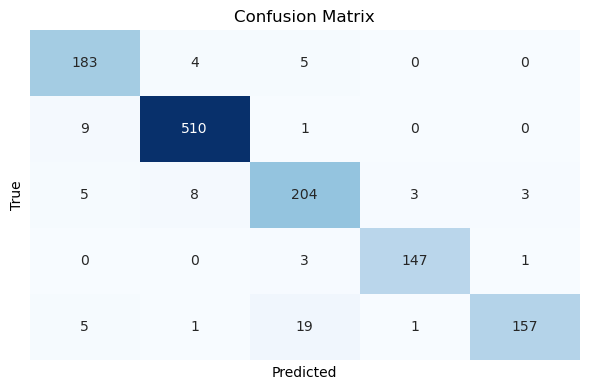

In [ ]:
evaluate_model(y_train_enc, y_pred_train, "kNN (Training set)", y_proba_train)

ROC Curve for kNN on training set

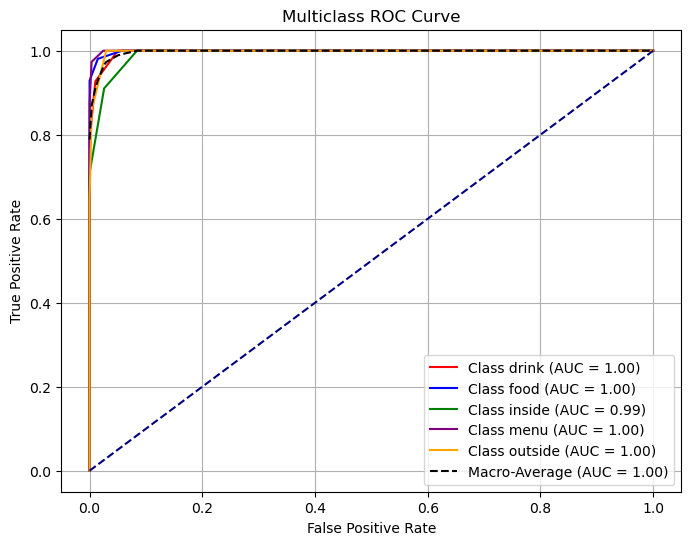

In [ ]:
plot_auc_curve(y_train_enc, y_proba_train, class_labels=label_encoder.classes_)

Predicting on validation set

In [ ]:
y_pred_val = knn.predict(X_val)
y_proba_val = knn.predict_proba(X_val)

Performance evaluation of kNN on validation set


Performance Metrics for kNN (Validation set):
Accuracy     : 0.8933
Precision    : 0.8975
Recall       : 0.8933
F1 Score     : 0.8929

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       338
           1       0.92      0.97      0.94       460
           2       0.84      0.88      0.86       466
           3       0.71      1.00      0.83        35
           4       0.95      0.79      0.87       398

    accuracy                           0.89      1697
   macro avg       0.87      0.91      0.88      1697
weighted avg       0.90      0.89      0.89      1697



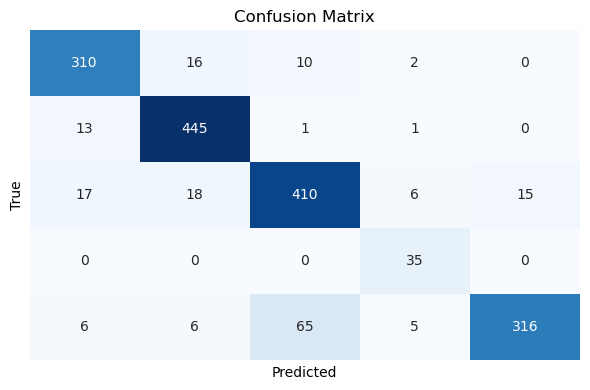

In [ ]:
evaluate_model(y_val_enc, y_pred_val, "kNN (Validation set)", y_proba_val)

ROC Curve for kNN on validation set

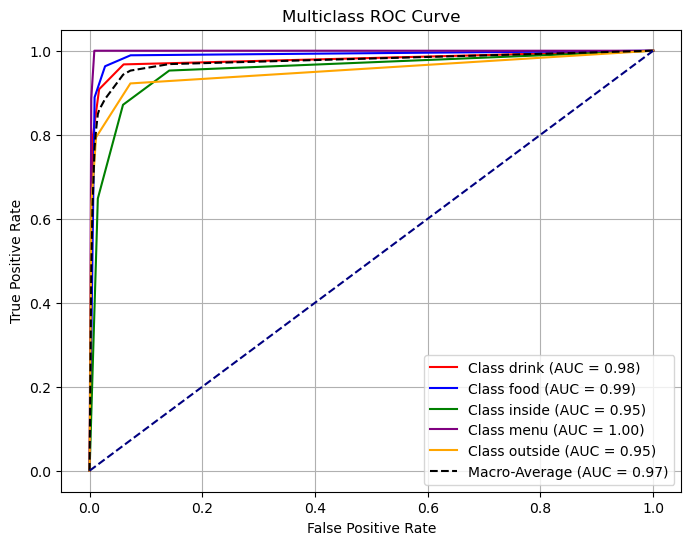

In [ ]:
plot_auc_curve(y_val_enc, y_proba_val, class_labels=label_encoder.classes_)

Predicting on testing set

In [ ]:
y_pred_test = knn.predict(X_test)
y_proba_test = knn.predict_proba(X_test)

Performance evaluation of kNN on testing set


Performance Metrics for kNN (Testing set):
Accuracy     : 0.9127
Precision    : 0.9150
Recall       : 0.9127
F1 Score     : 0.9126

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       242
           1       0.93      0.95      0.94       239
           2       0.92      0.86      0.89       278
           3       0.73      1.00      0.84        32
           4       0.90      0.86      0.88       125

    accuracy                           0.91       916
   macro avg       0.88      0.92      0.90       916
weighted avg       0.92      0.91      0.91       916



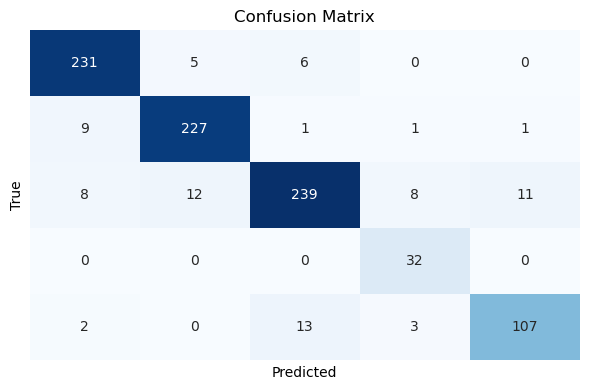

In [ ]:
evaluate_model(y_test_enc, y_pred_test, "kNN (Testing set)", y_proba_test)

ROC Curve for kNN on testing set

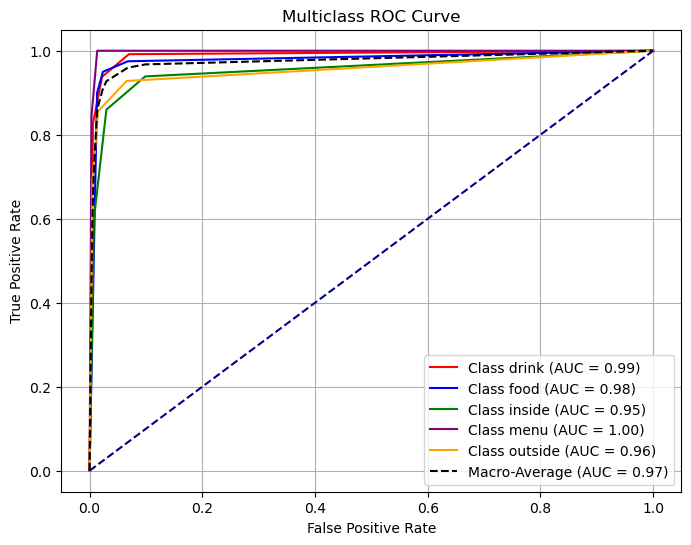

In [ ]:
plot_auc_curve(y_test_enc, y_proba_test, class_labels=label_encoder.classes_)

Tuning kNN

In [ ]:
k_values = [1, 3, 5, 7, 9]
metrics = ['euclidean', 'manhattan']
best_acc = 0
best_params = {}

print("Tuning kNN... \n")
for k in k_values:
    for metric in metrics:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train_enc)
        val_pred = knn.predict(X_val)
        acc = accuracy_score(y_val_enc, val_pred)
        print(f"k={k}, metric={metric}, val_acc={acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            best_params = {'k': k, 'metric': metric}

print(f"\n Best kNN Params: k={best_params['k']}, metric={best_params['metric']} (Val Acc = {best_acc:.4f})")

Tuning kNN... 

k=1, metric=euclidean, val_acc=0.8804
k=1, metric=manhattan, val_acc=0.8692
k=3, metric=euclidean, val_acc=0.8933
k=3, metric=manhattan, val_acc=0.8863
k=5, metric=euclidean, val_acc=0.8969
k=5, metric=manhattan, val_acc=0.8928
k=7, metric=euclidean, val_acc=0.8969
k=7, metric=manhattan, val_acc=0.8904
k=9, metric=euclidean, val_acc=0.8945
k=9, metric=manhattan, val_acc=0.8910

 Best kNN Params: k=5, metric=euclidean (Val Acc = 0.8969)


Training the model with best k value and metrics

In [ ]:
tuned_model = KNeighborsClassifier(n_neighbors=best_params['k'], metric=best_params['metric'])
tuned_model.fit(X_train, y_train_enc)

KNeighborsClassifier(metric='euclidean')

Predicting on training set after tuning

In [ ]:
y_pred_train_tuned = tuned_model.predict(X_train)
y_proba_train_tuned = tuned_model.predict_proba(X_train)

Performance evaluation of kNN on training set after tuning


Performance Metrics for kNN Tuned(Training set):
Accuracy     : 0.9346
Precision    : 0.9377
Recall       : 0.9346
F1 Score     : 0.9343

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       192
           1       0.96      0.98      0.97       520
           2       0.83      0.92      0.87       223
           3       0.97      0.97      0.97       151
           4       0.98      0.80      0.88       183

    accuracy                           0.93      1269
   macro avg       0.93      0.92      0.92      1269
weighted avg       0.94      0.93      0.93      1269



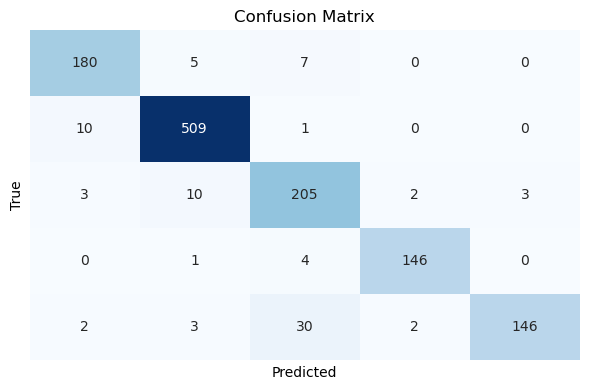

In [ ]:
evaluate_model(y_train_enc, y_pred_train_tuned, "kNN Tuned(Training set)", y_proba_train_tuned)

ROC Curve for kNN on training set after tuning

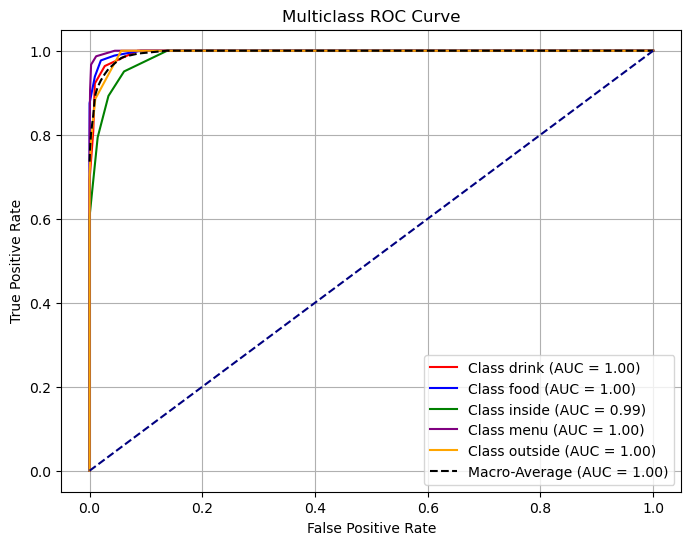

In [ ]:
plot_auc_curve(y_train_enc, y_proba_train_tuned, class_labels=label_encoder.classes_)

Predicting on validation set after tuning

In [ ]:
y_pred_val_tuned = tuned_model.predict(X_val)
y_proba_val_tuned = tuned_model.predict_proba(X_val)

Performance evaluation of kNN on validation set after tuning


Performance Metrics for kNN Tuned (Validation set):
Accuracy     : 0.8969
Precision    : 0.9019
Recall       : 0.8969
F1 Score     : 0.8965

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       338
           1       0.92      0.96      0.94       460
           2       0.84      0.89      0.87       466
           3       0.71      1.00      0.83        35
           4       0.97      0.79      0.87       398

    accuracy                           0.90      1697
   macro avg       0.87      0.91      0.88      1697
weighted avg       0.90      0.90      0.90      1697



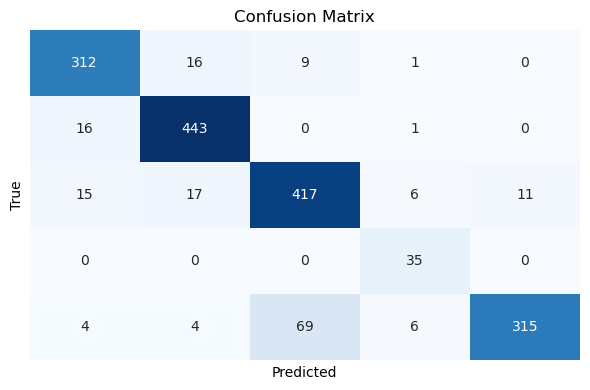

In [ ]:
evaluate_model(y_val_enc, y_pred_val_tuned, "kNN Tuned (Validation set)", y_proba_val_tuned)

ROC Curve for kNN on validation set after tuning

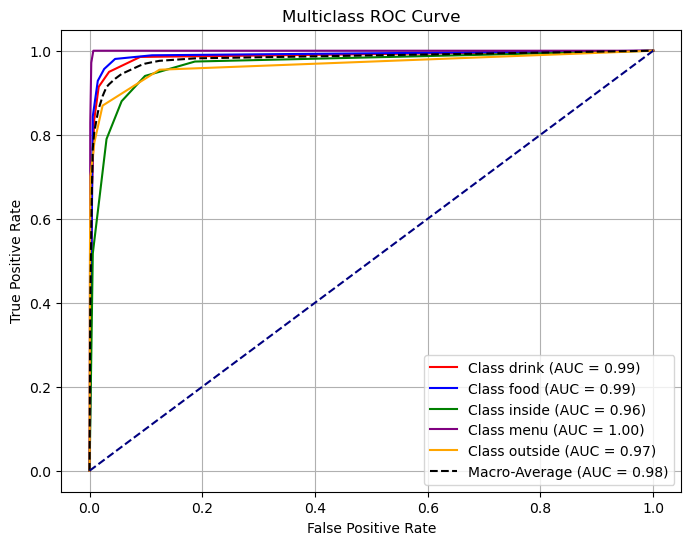

In [ ]:
plot_auc_curve(y_val_enc, y_proba_val_tuned, class_labels=label_encoder.classes_)

Predicting on testing set after tuning

In [ ]:
y_pred_test_tuned = tuned_model.predict(X_test)
y_proba_test_tuned = tuned_model.predict_proba(X_test)

Performance evaluation of kNN on testing set after tuning


Performance Metrics for kNN Tuned (Testing set):
Accuracy     : 0.9072
Precision    : 0.9096
Recall       : 0.9072
F1 Score     : 0.9071

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       242
           1       0.90      0.95      0.93       239
           2       0.90      0.87      0.88       278
           3       0.74      0.97      0.84        32
           4       0.94      0.83      0.88       125

    accuracy                           0.91       916
   macro avg       0.88      0.91      0.89       916
weighted avg       0.91      0.91      0.91       916



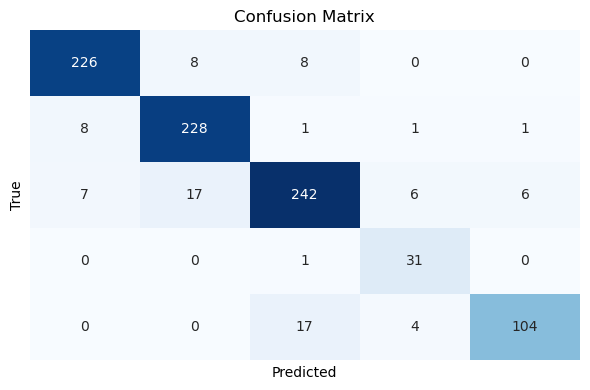

In [ ]:
evaluate_model(y_test_enc, y_pred_test_tuned, "kNN Tuned (Testing set)", y_proba_test_tuned)

ROC Curve for kNN on testing set after tuning

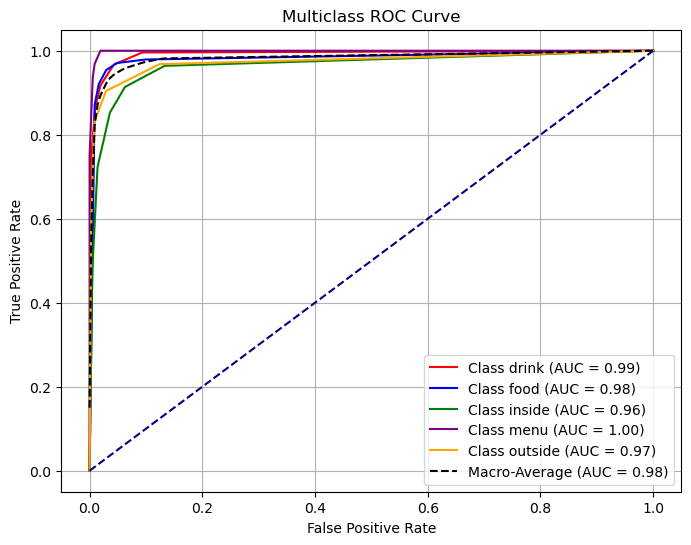

In [ ]:
plot_auc_curve(y_test_enc, y_proba_test_tuned, class_labels=label_encoder.classes_)

Exporting the tuned model and label encoder as pickle file

In [ ]:
with open("knn_model.pkl", "wb") as f:
    pickle.dump(tuned_model, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

### SVM Model + Evaluation

**Author**: Riya Kalpeshkumar Shah

This presents the implementation of a Support Vector Machine (SVM) for classifying Yelp images. It includes feature selection, model training, and performance analysis through confusion matrix and AUC metrics.


In [11]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 20.2 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [3]:
def load_images_from_folders(root_folder, img_size=64):
    X, y = [],[]
    class_names = []

    for label in sorted(os.listdir(root_folder)):
        class_path = os.path.join(root_folder, label)
        if not os.path.isdir(class_path):
            continue
        class_names.append(label)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (img_size, img_size))
                X.append(img.flatten())  # Flatten the image to 1D
                y.append(label)
            except:
                continue
    return np.array(X), np.array(y), class_names


In [4]:
train_path = '/content/final_processed_data/train'
val_path = '/content/final_processed_data/val'
test_path = '/content/final_processed_data/test'

X_train, y_train, class_names = load_images_from_folders(train_path)
X_val, y_val, _ = load_images_from_folders(val_path)
X_test, y_test, _ = load_images_from_folders(test_path)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (36181, 12288)
Val shape: (4452, 12288)
Test shape: (4488, 12288)


In [5]:
from sklearn.model_selection import train_test_split

# Reduce to half the size (~18,090 samples)
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=0.3,
    random_state=42,
    stratify=y_train  # important to keep class balance
)

print("Reduced Train shape:", X_train_small.shape)


Reduced Train shape: (10854, 12288)


In [15]:
print(len(X_train), len(y_train))  # should be same


36181 36181


In [6]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_small)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)


In [7]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=500)  # choose k based on memory
X_train_sel = selector.fit_transform(X_train_small, y_train_enc)
X_val_sel = selector.transform(X_val)
X_test_sel = selector.transform(X_test)


In [8]:
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm.fit(X_train_sel, y_train_enc)


SVC(C=10, probability=True)

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = svm.predict(X_test_sel)

print("Confusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred, target_names=class_names))


Confusion Matrix:
[[  87  193   90    0   13]
 [  40 2065  220    0   34]
 [  24  379  827    1   87]
 [   1   20    7    0    4]
 [  16  110  222    0   48]]

Classification Report:
              precision    recall  f1-score   support

       drink       0.52      0.23      0.32       383
        food       0.75      0.88      0.81      2359
      inside       0.61      0.63      0.62      1318
        menu       0.00      0.00      0.00        32
     outside       0.26      0.12      0.16       396

    accuracy                           0.67      4488
   macro avg       0.43      0.37      0.38      4488
weighted avg       0.64      0.67      0.65      4488



In [10]:
y_proba = svm.predict_proba(X_test_sel)
try:
    auc = roc_auc_score(y_test_enc, y_proba, multi_class='ovr')
    print("AUC Score:", auc)
except:
    print("AUC score could not be calculated.")


AUC Score: 0.7682385872660695


### CNN Model + Evaluation

**Author**: Om Kiranbhai Patel

This implements a Convolutional Neural Network (CNN) to classify Yelp images into categories such as food, drink, inside, outside, and menu. It includes model architecture, training, evaluation, and performance visualization through confusion matrix and AUC. The CNN is trained using preprocessed data and fine-tuned to maximize validation performance.


Prompt given to LLM:

First Propmt: now we need to do buildd CNN model for the yelp Photos dataset

Last Prompt: ok done so check this graph and tell me how do i know if m model is overfitting or not?

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [9]:
# Install unrar to handle .rar files
!apt-get install unrar

# Extract the .rar file
!unrar x /content/drive/MyDrive/Colab\ Notebooks/Processed\ data/final_processed_data.rar /content/final_processed_data



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/Colab Notebooks/Processed data/final_processed_data.rar

No files to extract


In [11]:
import os
os.listdir("/content/drive/MyDrive/Colab Notebooks/Processed data")


['final_processed_data.rar', 'photos.json']

In [12]:
!unrar l "/content/drive/MyDrive/Colab Notebooks/Processed data/final_processed_data.rar"


Streaming output truncated to the last 5000 lines.
    ..A....     19413  2025-05-28 02:21  final_processed_data/train/outside/AodVccIykwJUd4a5ebofNQ.jpg
    ..A....     27557  2025-05-28 02:23  final_processed_data/train/outside/aOfnK-6_B99KUtM3m0MdLQ.jpg
    ..A....     14144  2025-05-28 02:25  final_processed_data/train/outside/aOgrimBG9yTPjhVvvL9Tow.jpg
    ..A....     23816  2025-05-28 02:30  final_processed_data/train/outside/AOoALJvONwjiTH_3rWjP-w.jpg
    ..A....     24773  2025-05-28 02:31  final_processed_data/train/outside/AOpLEXZO8AR3itilGLvblw.jpg
    ..A....     21550  2025-05-28 02:29  final_processed_data/train/outside/aoSsaGVkCS6yL4PRZ9BSdQ.jpg
    ..A....     19318  2025-05-28 02:33  final_processed_data/train/outside/aoY0E9yigDOVsQI5T9T-kg.jpg
    ..A....     23132  2025-05-28 02:23  final_processed_data/train/outside/aOYOa5VijKGh_IIBsmQkiA.jpg
    ..A....     27767  2025-05-28 02:30  final_processed_data/train/outside/ap1FQtpFhrHFTKsh6mQQRA.jpg
    ..A....     21831 

In [13]:
!unrar x "/content/drive/MyDrive/Colab Notebooks/Processed data/final_processed_data.rar"


Streaming output truncated to the last 5000 lines.
Extracting  final_processed_data/train/outside/Amnj1WgWAZZ_GTCKw6SlaQ.jpg      89%  OK 
Extracting  final_processed_data/train/outside/AmOYmlMkZuPMMhs6OiEg3w.jpg      89%  OK 
Extracting  final_processed_data/train/outside/AMs-eCVwDKmJE6iBK6js0w.jpg      89%  OK 
Extracting  final_processed_data/train/outside/amvOLbJcr-7PcD4GrnOCQg.jpg      89%  OK 
Extracting  final_processed_data/train/outside/AmwHg9k03XXBUkFFPmqF-g.jpg      89%  OK 
Extracting  final_processed_data/train/outside/An4cR5bvcDrnLaqhSUtA-A.jpg      89%  OK 
Extracting  final_processed_data/train/outside/aN7f0NoB2ea5TJOOim2Jhg.jpg      89%  OK 
Extracting  final_processed_data/train/outside/AnAK_o366JeIhhwQ_OnRNQ.jpg      89%  OK 
Extracting  final_processed_data/train/outside/ANB9fjfnOdRm97uwxpF3JA.jpg      89%  OK 
Extracting  final_processed_data/train/outside/Anbn64bt5yRL7eKJUnaJoQ.jpg   

In [14]:
import os

# Check folder structure
os.listdir("/content/final_processed_data")


['train',
 'menu',
 'food',
 'test',
 'inside',
 'processing_log.json',
 'val',
 'metadata',
 'drink',
 'outside',
 'split_info.json']

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    '/content/final_processed_data/train',
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical'
)

val_gen = datagen.flow_from_directory(
    '/content/final_processed_data/val',
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical'
)

test_gen = datagen.flow_from_directory(
    '/content/final_processed_data/test',
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)


Found 36181 images belonging to 5 classes.
Found 4452 images belonging to 5 classes.
Found 4488 images belonging to 5 classes.


# Build the CNN Architecture

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Create the CNN model
cnn_model = Sequential()

# Convolution + Pooling Layer 1
cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution + Pooling Layer 2
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution + Pooling Layer 3
cnn_model.add(Conv2D(128, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten and Dense Layers
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(5, activation='softmax'))  # 5 classes

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])


# Train the Model

In [30]:
# Train the CNN model
history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)


Epoch 1/5
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 1200s 530ms/step - accuracy: 0.8215 - loss: 0.5222 - val_accuracy: 0.8464 - val_loss: 0.4484
Epoch 2/5
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 1191s 526ms/step - accuracy: 0.8351 - loss: 0.4754 - val_accuracy: 0.8553 - val_loss: 0.4197
Epoch 3/5
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 1181s 522ms/step - accuracy: 0.8516 - loss: 0.4368 - val_accuracy: 0.8621 - val_loss: 0.4085
Epoch 4/5
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 1184s 524ms/step - accuracy: 0.8589 - loss: 0.4133 - val_accuracy: 0.8614 - val_loss: 0.3959
Epoch 5/5
2262/2262 ━━━━━━━━━━━━━━━━━━━━ 1182s 523ms/step - accuracy: 0.8711 - loss: 0.3693 - val_accuracy: 0.8610 - val_loss: 0.4049


# Evaluate with Confusion Matrix

In [31]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

281/281 ━━━━━━━━━━━━━━━━━━━━ 40s 142ms/step


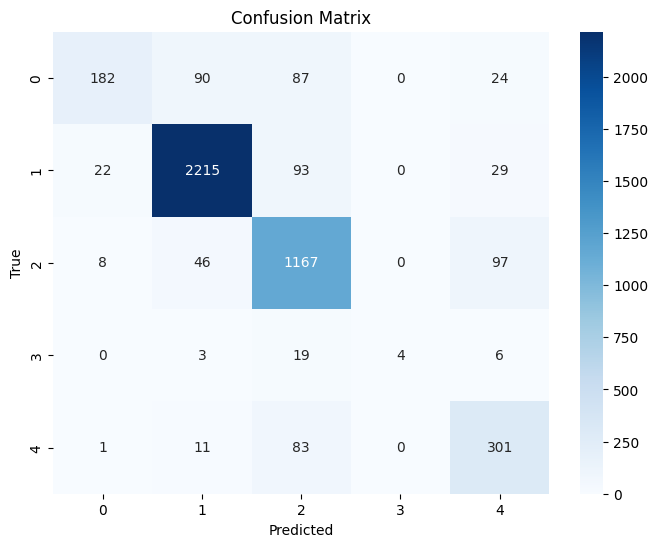

              precision    recall  f1-score   support

       drink       0.85      0.48      0.61       383
        food       0.94      0.94      0.94      2359
      inside       0.81      0.89      0.84      1318
        menu       1.00      0.12      0.22        32
     outside       0.66      0.76      0.71       396

    accuracy                           0.86      4488
   macro avg       0.85      0.64      0.66      4488
weighted avg       0.87      0.86      0.86      4488



In [32]:
# Get predictions
Y_pred_probs = cnn_model.predict(test_gen)
Y_pred = np.argmax(Y_pred_probs, axis=1)
Y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print(classification_report(Y_true, Y_pred, target_names=test_gen.class_indices.keys()))

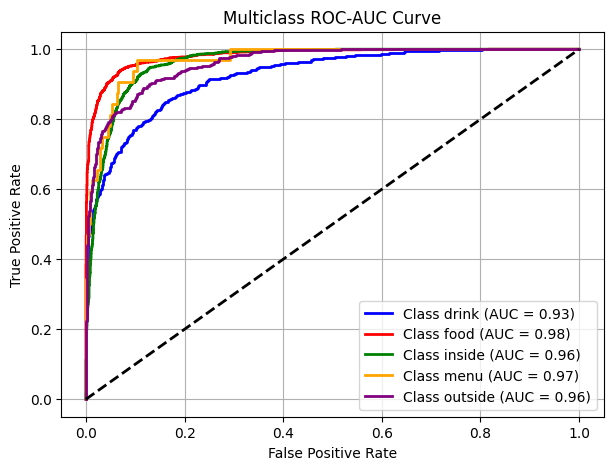

In [37]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np

n_classes = 5
Y_true_bin = label_binarize(Y_true, classes=[0, 1, 2, 3, 4])

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_true_bin[:, i], Y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(7, 5))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
class_names = list(test_gen.class_indices.keys())

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC-AUC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [34]:
loss, acc = cnn_model.evaluate(test_gen)
print(f"Test Accuracy: {acc:.4f}")


281/281 ━━━━━━━━━━━━━━━━━━━━ 41s 147ms/step - accuracy: 0.7934 - loss: 0.6463
Test Accuracy: 0.8621


### DNN Model + Evaluation

**Author**: Arish Panjwani

This demonstrates a Deep Neural Network (DNN) for multi-class image classification on the Yelp dataset. It includes dropout and batch normalization techniques, training metrics, confusion matrix, and AUC analysis.


### Model Tuning + Interpretability

**Author**: Kanika .

This contains model tuning and interpretability analysis using LIME. The goal is to evaluate feature importance, perform empirical tuning, and document improvements in model performance.


### Cross-Validation Analysis

**Author**: Tanzima Mohammadyasin Shaikh

This applies k-fold cross-validation to assess the generalization performance of the trained models. It documents validation accuracy across folds and summarizes variance in performance.


### Hyperparameter Tuning

**Author**: Advait Manishkumar Pandit

This explores hyperparameter optimization for selected models (SVM, CNN, and DNN). It documents parameter combinations, validation scores, and visual comparisons to highlight performance trends.


### Ensemble Modeling

**Author**: Nischal Pradhan

This builds an ensemble classifier using top-performing individual models. It compares ensemble performance with base models using accuracy, AUC, and confusion matrix.
